In [1]:
import fitz
from pathlib import Path

# Configuration - all parameters in one place
PDF_FOLDER = Path("../data/pdfs")
CHUNK_SIZE = 800  # Size of each text chunk
CHUNK_OVERLAP = 100  # Overlap between chunks to preserve context
EMBEDDING_BATCH_SIZE = 32
TOP_K = 5
EMBEDDING_MODEL = "BAAI/bge-small-en-v1.5"
OLLAMA_MODEL = "qwen3:4b"

pages = []

# Load PDFs with error handling
try:
    for pdf_path in PDF_FOLDER.glob("*.pdf"):
        try:
            doc = fitz.open(pdf_path)
            for page_num, page in enumerate(doc):
                pages.append({
                    "text": page.get_text(),
                    "page": page_num,
                    "source": pdf_path.name
                })
        except Exception as e:
            print(f"Error loading {pdf_path}: {e}")
except FileNotFoundError:
    print(f"PDF folder not found at {PDF_FOLDER}")

print(f"Loaded {len(pages)} pages")

Loaded 21 pages


In [2]:
print(pages[0])

{'text': 'The Power of Noise: Redefining Retrieval for RAG Systems\nFlorin Cuconasu∗\ncuconasu@diag.uniroma1.it\nSapienza University of Rome\nRome, Italy\nGiovanni Trappolini∗\ntrappolini@diag.uniroma1.it\nSapienza University of Rome\nRome, Italy\nFederico Siciliano\nsiciliano@diag.uniroma1.it\nSapienza University of Rome\nRome, Italy\nSimone Filice\nfilice.simone@gmail.com\nTechnology Innovation Institute\nHaifa, Israel\nCesare Campagnano\ncampagnano@di.uniroma1.it\nSapienza University of Rome\nRome, Italy\nYoelle Maarek\nyoelle@yahoo.com\nTechnology Innovation Institute\nHaifa, Israel\nNicola Tonellotto\nnicola.tonellotto@unipi.it\nUniversity of Pisa\nPisa, Italy\nFabrizio Silvestri\nfsilvestri@diag.uniroma1.it\nSapienza University of Rome\nRome, Italy\nABSTRACT\nRetrieval-Augmented Generation (RAG) has recently emerged as\na method to extend beyond the pre-trained knowledge of Large\nLanguage Models by augmenting the original prompt with relevant\npassages or documents retrieved by 

### pdf ingestion


In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP
)

chunks = []

for page in pages:
    page_chunks = splitter.split_text(page["text"])
    for chunk in page_chunks:
        chunks.append({
            "text": chunk,
            "page": page["page"],
            "source": page["source"],
            "chunk_id": str(len(chunks))  # Add ID during creation
        })

print(f"Created {len(chunks)} chunks")

c:\Users\RAAJ\Desktop\code\rag101\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Created 160 chunks


### Timing info (already measured above)

In [4]:
print("Chunks created and chunking time displayed above")

Chunks created and chunking time displayed above


In [5]:
print(chunks[0])  # Show first chunk to verify structure

{'text': 'The Power of Noise: Redefining Retrieval for RAG Systems\nFlorin Cuconasu∗\ncuconasu@diag.uniroma1.it\nSapienza University of Rome\nRome, Italy\nGiovanni Trappolini∗\ntrappolini@diag.uniroma1.it\nSapienza University of Rome\nRome, Italy\nFederico Siciliano\nsiciliano@diag.uniroma1.it\nSapienza University of Rome\nRome, Italy\nSimone Filice\nfilice.simone@gmail.com\nTechnology Innovation Institute\nHaifa, Israel\nCesare Campagnano\ncampagnano@di.uniroma1.it\nSapienza University of Rome\nRome, Italy\nYoelle Maarek\nyoelle@yahoo.com\nTechnology Innovation Institute\nHaifa, Israel\nNicola Tonellotto\nnicola.tonellotto@unipi.it\nUniversity of Pisa\nPisa, Italy\nFabrizio Silvestri\nfsilvestri@diag.uniroma1.it\nSapienza University of Rome\nRome, Italy\nABSTRACT\nRetrieval-Augmented Generation (RAG) has recently emerged as', 'page': 0, 'source': 'rag_power.pdf', 'chunk_id': '0'}


## Embeddings

In [6]:
import torch
import torchvision

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA:", torch.version.cuda)
print("GPU available:", torch.cuda.is_available())

Torch: 2.11.0+cu128
Torchvision: 0.26.0+cu128
CUDA: 12.8
GPU available: True


In [7]:
# Torch already checked above

In [8]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(EMBEDDING_MODEL, device="cuda")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1771.79it/s]


### we only want to embed the texts

In [9]:
chunk_texts = [chunk["text"] for chunk in chunks]

In [10]:
print(len(chunk_texts))
import time

start = time.perf_counter()

embeddings = embedding_model.encode(
    chunk_texts,
    batch_size=EMBEDDING_BATCH_SIZE,
    show_progress_bar=True
)

end = time.perf_counter()

elapsed = end - start

print(f"Time: {elapsed:.2f} sec")
print(f"Chunks: {len(chunk_texts)}")
print(f"Chunks/sec: {len(chunk_texts)/elapsed:.2f}")

160


Batches: 100%|██████████| 5/5 [00:02<00:00,  2.15it/s]

Time: 2.36 sec
Chunks: 160
Chunks/sec: 67.87


In [11]:
print(embeddings.shape)

(160, 384)


In [12]:
embeddings[0]

array([-5.57709076e-02,  3.42951715e-02,  9.15563013e-03, -2.94322576e-02,
       -1.95705537e-02,  7.27067189e-03, -2.16339193e-02,  1.25215445e-02,
        5.39246351e-02, -2.57572625e-02,  4.22952548e-02, -1.98571328e-02,
        4.17924710e-02,  1.74643341e-02,  5.42131774e-02,  4.09557521e-02,
        1.41746299e-02,  8.21188614e-02,  5.20440191e-03, -5.10422252e-02,
        3.96604389e-02,  8.13990715e-04,  1.29957059e-02, -3.22931372e-02,
       -2.88615208e-02, -9.52639803e-03, -1.65971871e-02, -5.60132712e-02,
       -8.47699195e-02, -2.43441537e-01,  2.76107178e-03, -3.45309526e-02,
        8.15761462e-02,  1.82150342e-02, -4.26638825e-03,  1.09008644e-02,
       -2.66933208e-03,  2.10109800e-02, -2.37870980e-02,  4.08135690e-02,
        8.06503929e-03,  1.25457393e-02, -6.55661942e-03, -3.08234524e-02,
       -5.65570965e-02, -1.26840891e-02,  1.94252171e-02, -4.65092957e-02,
       -6.83431849e-02,  4.72239777e-02, -4.30288389e-02,  7.06134969e-03,
       -2.15434767e-02,  

In [13]:
query = "some uses of rag"
query_embedding = embedding_model.encode(query, device="cuda")
print(query_embedding.shape)

(384,)


In [14]:
# Verify all data matches
assert len(chunks) == len(embeddings), "Mismatch between chunks and embeddings"
print(f"Chunks: {len(chunks)}, Embeddings: {len(embeddings)} ✓")

Chunks: 160, Embeddings: 160 ✓


In [15]:
import chromadb

client = chromadb.PersistentClient(path="./chroma_db")

In [16]:
### creating a collection (like a table in a database)
collection = client.get_or_create_collection(name="documents")

In [17]:
chunks[0].keys()

dict_keys(['text', 'page', 'source', 'chunk_id'])

In [18]:
# Extract data for ChromaDB
documents = [chunk["text"] for chunk in chunks]
metadatas = [
    {
        "source": chunk["source"],
        "page": chunk["page"],
        "chunk_id": chunk["chunk_id"]
    }
    for chunk in chunks
]
ids = [chunk["chunk_id"] for chunk in chunks]

In [19]:
# Verify all data matches before adding to ChromaDB
assert len(documents) == len(metadatas) == len(ids) == len(embeddings), "Data length mismatch"
print(f"Documents: {len(documents)}")
print(f"Metadatas: {len(metadatas)}")
print(f"IDs: {len(ids)}")
print(f"Embeddings: {len(embeddings)}")
print("All data aligned ✓")

Documents: 160
Metadatas: 160
IDs: 160
Embeddings: 160
All data aligned ✓


In [20]:
# Add all data to ChromaDB collection
collection.add(
    ids=ids,
    documents=documents,
    embeddings=embeddings.tolist(),
    metadatas=metadatas
)
print(f"Added {collection.count()} documents to ChromaDB")

Added 160 documents to ChromaDB


In [21]:
collection.count()
collection.peek()


{'ids': ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'],
 'embeddings': array([[-0.05577091,  0.03429517,  0.00915563, ...,  0.02624634,
          0.02213062, -0.00282543],
        [-0.0774889 ,  0.03270463,  0.00300361, ...,  0.09887322,
          0.03398248, -0.04074974],
        [-0.09981596,  0.02082373, -0.00858553, ...,  0.1008377 ,
          0.0320918 , -0.03111182],
        ...,
        [-0.03546707,  0.0591628 , -0.01676207, ...,  0.00902497,
          0.06281515,  0.01804019],
        [-0.0627249 ,  0.0359627 ,  0.01805033, ...,  0.05578906,
          0.0109489 , -0.0100734 ],
        [-0.07450041,  0.02421362, -0.00227971, ...,  0.03415185,
          0.04281569,  0.01556837]], shape=(10, 384)),
 'documents': ['The Power of Noise: Redefining Retrieval for RAG Systems\nFlorin Cuconasu∗\ncuconasu@diag.uniroma1.it\nSapienza University of Rome\nRome, Italy\nGiovanni Trappolini∗\ntrappolini@diag.uniroma1.it\nSapienza University of Rome\nRome, Italy\nFederico Siciliano\nsicilian

## VECTOR DATABASES IS COMPLETED!!
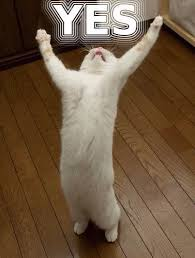

Our next step would be to ask a question and see if the vectordb can retreive the relevant chunks

In [22]:
query = "noise in rag"
query_embedding = embedding_model.encode(query, device="cuda")

In [23]:
### query the collection
results = collection.query(
    query_embeddings=[query_embedding.tolist()],
    n_results=5
)
results.keys()

dict_keys(['ids', 'embeddings', 'documents', 'uris', 'included', 'data', 'metadatas', 'distances'])

In [24]:
for i in range(5):

    print("=" * 80)

    print(
        f"Rank: {i+1}"
    )

    print(
        f"Distance: {results['distances'][0][i]:.4f}"
    )

    print(
        results["metadatas"][0][i]
    )

    print()

    print(
        results["documents"][0][i][:500]
    )

Rank: 1
Distance: 0.6736
{'page': 2, 'source': 'rag_survey.pdf', 'chunk_id': '113'}

indicating a growing interest and research activity in the field of RAG applications. 
Fig. 2. Research Method
Rank: 2
Distance: 0.6964
{'page': 0, 'source': 'rag_power.pdf', 'chunk_id': '0'}

The Power of Noise: Redefining Retrieval for RAG Systems
Florin Cuconasu∗
cuconasu@diag.uniroma1.it
Sapienza University of Rome
Rome, Italy
Giovanni Trappolini∗
trappolini@diag.uniroma1.it
Sapienza University of Rome
Rome, Italy
Federico Siciliano
siciliano@diag.uniroma1.it
Sapienza University of Rome
Rome, Italy
Simone Filice
filice.simone@gmail.com
Technology Innovation Institute
Haifa, Israel
Cesare Campagnano
campagnano@di.uniroma1.it
Sapienza University of Rome
Rome, Italy
Yoelle Maarek
yoe
Rank: 3
Distance: 0.7153
{'source': 'rag_power.pdf', 'page': 8, 'chunk_id': '69'}

, ⋆, Q]. We
find that when we introduce random documents, the entropy of
the systems has a 3X increase. Although these experiments show a


In [25]:
def retrieve(query, k=TOP_K):
    """Retrieve top-k relevant chunks using ChromaDB (L2 distance metric)"""
    query_embedding = embedding_model.encode(query, device="cuda")
    results = collection.query(
        query_embeddings=[query_embedding.tolist()],
        n_results=k
    )
    return results

In [26]:
### pretty print results
def show_results(results):
    """Pretty print retrieval results with metadata"""
    for i in range(len(results["documents"][0])):
        print("=" * 80)
        print(f"Rank: {i+1}")
        print(f"Source: {results['metadatas'][0][i]['source']}")
        print(f"Page: {results['metadatas'][0][i]['page']}")
        print(f"Distance: {results['distances'][0][i]:.4f}")
        print()
        print(results["documents"][0][i])

In [27]:
results = retrieve("full form of rag", k=5)
show_results(results)

Rank: 1
Source: rag_survey.pdf
Page: 2
Distance: 0.6228

indicating a growing interest and research activity in the field of RAG applications. 
Fig. 2. Research Method
Rank: 2
Source: rag_power.pdf
Page: 0
Distance: 0.6262

ate more accurate answers at inference time. At their core, RAG
systems consist of two fundamental components: a retriever and a
generator. The retriever is responsible for invoking an external IR
system (dense and/or sparse) and feeding the selected results to a
generator component.
This study focuses on the IR aspect of RAG, posing the following
research question: “What characteristics are desirable in a retriever
to optimize prompt construction for RAG systems? Are current re-
trievers ideal?". We focus on the three main types of documents
719
Rank: 3
Source: rag_power.pdf
Page: 0
Distance: 0.6869

The Power of Noise: Redefining Retrieval for RAG Systems
Florin Cuconasu∗
cuconasu@diag.uniroma1.it
Sapienza University of Rome
Rome, Italy
Giovanni Trappolini∗
trappo

In [28]:
def build_context(results):
    """Combine retrieved chunks into a single context string"""
    context = "\n\n".join(results["documents"][0])
    return context

In [29]:
context = build_context(
    retrieve(
        "applications of rag"
    )
)

print(context[:2000])

indicating a growing interest and research activity in the field of RAG applications. 
Fig. 2. Research Method

3784	
Muhammad Arslan  et al. / Procedia Computer Science 246 (2024) 3781–3790
 
 
 
 
 
 
 
 
 
 
 
 
Fig. 3. Evolution of Research Publications on RAG Applications 
3. Applications of RAG with LLMs 
Upon thorough examination of the selected papers focusing on RAG applications, we uncovered a vast array of 
diverse applications. These findings are distilled into a comprehensive table format (see Table 1), detailing three 
crucial aspects: 1) Use case with RAG, 2) Used datasets/benchmarks, and 3) Application area. Noteworthy 
applications span various domains, including biomedical, financial, and medical inquiries, alongside text 
summarization and book review generation. RAG’s versatility extends to commonsense QA, table-based queries,

The Power of Noise: Redefining Retrieval for RAG Systems
Florin Cuconasu∗
cuconasu@diag.uniroma1.it
Sapienza University of Rome
Rome, Italy


In [ ]:
from ollama import chat

def answer_question(query):
    """Retrieve context and generate answer using local LLM"""
    results = retrieve(query)
    context = build_context(results)
    
    # Format sources for citation
    sources = ", ".join([
        f"{m['source']} (p.{m['page']})" 
        for m in results['metadatas'][0]
    ])
    
    prompt = f"""You are a helpful assistant.

Answer ONLY using the provided context.
If the answer is not found in the context, say "I don't know."
After your answer, cite the sources you used.

Context:
{context}

Question: {query}

Sources: {sources}"""

    try:
        response = chat(
            model=OLLAMA_MODEL,
            messages=[{"role": "user", "content": prompt}]
        )
        return response["message"]["content"]
    except Exception as e:
        return f"Error generating answer: {e}"

# Test Ollama connection
try:
    chat(model=OLLAMA_MODEL, messages=[{"role": "user", "content": "hello"}])
    print(f"✓ Connected to Ollama model: {OLLAMA_MODEL}")
except Exception as e:
    print(f"✗ Ollama connection failed: {e}")
    print(f"Make sure Ollama is running: ollama serve")

In [31]:
## Debug: See what's being retrieved
query = "what are these pdfs about?"
results = retrieve(query)

print("=" * 80)
print(f"Query: '{query}'")
print("=" * 80)
print("\nTop results retrieved:\n")

for i in range(len(results["documents"][0])):
    print(f"[Rank {i+1}] Distance: {results['distances'][0][i]:.4f} | {results['metadatas'][0][i]['source']} (Page {results['metadatas'][0][i]['page']})")
    print(f"Text: {results['documents'][0][i][:300]}...")
    print()

print("=" * 80)
print("Full context being sent to LLM:")
print("=" * 80)
context = build_context(results)
print(context)
print("=" * 80)

Query: 'what are these pdfs about?'

Top results retrieved:

[Rank 1] Distance: 0.6961 | rag_power.pdf (Page 8)
Text: retrieved documents only [I, q, Q] (first row), as determined by a Wilcoxon test (p-value < 0.01).
Random from Reddit
Random Words
#
# q
1
2
3
4
5
8
10
1
2
3
4
5
8
10
0
0.1620
0.1866
0.1876
0.1866
0.1921
0.2198
0.2108
0.1620
0.1866
0.1876
0.1866
0.1921
0.2198
0.2108
1
0.1693*
0.1931
0.1845*
0.1907
0...

[Rank 2] Distance: 0.7620 | rag_survey.pdf (Page 6)
Text: - Technical product information QA [17] 
- Natural QA [24] 
- Professional knowledge QA [38] 
- Multicultural enterprise QA [40] 
- Open-domain QA and fact verification [46] 
- Short-form open-domain QA [46] 
- Generative QA and informative conversations [29] 
- Pharma industry regulatory compliance...

[Rank 3] Distance: 0.7785 | rag_power.pdf (Page 6)
Text: 0.2174
0.2450
0.2502
0.2499
0.2420
-
0.2108
0.2589
0.2734
0.2835
0.2935
0.2853
-
15
0.2018
0.2354
0.2551
0.2530
-
-
-
0.2243
0.2686
0.2790
0.2928
-
-
-
16
0.

In [32]:
## Check what PDFs are in the database
unique_sources = set(m['source'] for docs in [collection.get()['metadatas']] for m in docs)
print("PDFs in database:")
for source in sorted(unique_sources):
    count = sum(1 for m in collection.get()['metadatas'] if m['source'] == source)
    print(f"  - {source}: {count} chunks")

print(f"\nTotal chunks: {collection.count()}")
print("\n⚠️  Issue: The question 'what are these pdfs about?' is too vague for chunked content.")
print("Try asking specific questions instead:\n")


PDFs in database:
  - rag_power.pdf: 98 chunks
  - rag_survey.pdf: 62 chunks

Total chunks: 160

⚠️  Issue: The question 'what are these pdfs about?' is too vague for chunked content.
Try asking specific questions instead:



In [33]:
## Test with specific questions
test_queries = [
    "What is RAG?",
    "How does retrieval augmented generation work?",
    "What are the applications of RAG?",
    "How does RAG improve question answering?",
]

print("Testing specific queries:\n")
for test_query in test_queries:
    print(f"Query: '{test_query}'")
    result = retrieve(test_query, k=1)
    distance = result['distances'][0][0]
    source = result['metadatas'][0][0]['source']
    text = result['documents'][0][0][:200]
    print(f"  → Distance: {distance:.4f} | {source}")
    print(f"  → {text}...")
    print()


Testing specific queries:

Query: 'What is RAG?'
  → Distance: 0.5232 | rag_survey.pdf
  → and clinical decision-making, among others. It further encompasses educational decision making, textbook question 
answering, and enterprise search functionalities. RAG is instrumental in sentiments c...

Query: 'How does retrieval augmented generation work?'
  → Distance: 0.2995 | rag_power.pdf
  → Rome, Italy
ABSTRACT
Retrieval-Augmented Generation (RAG) has recently emerged as
a method to extend beyond the pre-trained knowledge of Large
Language Models by augmenting the original prompt with re...

Query: 'What are the applications of RAG?'
  → Distance: 0.4409 | rag_survey.pdf
  → indicating a growing interest and research activity in the field of RAG applications. 
Fig. 2. Research Method...

Query: 'How does RAG improve question answering?'
  → Distance: 0.4190 | rag_power.pdf
  → internal memory. In [60], they test the model’s (in)ability to ground
references.
In this paper, we want to prov

In [35]:
## Now generate actual answers with a specific question
print("=" * 80)
print("FULL RAG PIPELINE TEST - Specific Question")
print("=" * 80)

specific_query = "What is Retrieval Augmented Generation and how does it work?"
answer = answer_question(specific_query)

print(f"\nQuestion: {specific_query}\n")
print("Answer:")
print(answer)


FULL RAG PIPELINE TEST - Specific Question


NameError: name 'answer_question' is not defined